In [1]:
x = [1,2,3,10]
y = [10, 20, 30, 40]
Z=[X+Y for X,Y in zip(x,y)]   #returns a list of tuples, combines i-th element together
print(list(Z))

def f(X,Y):
    return X+Y

Z=map(f,x,y) #applies function to every element in list
print(list(Z))

[11, 22, 33, 50]
[11, 22, 33, 50]


In [2]:
import numpy as np

#define R,S,P
R="R"
P="P"
S="S"
#player's input
player=input(f"Give S for scissors, R for rock or P for paper: ")

#computer output
rps = np.array(['R','P','S'])
indx = np.random.randint(0, len(rps), 1)
print(f"computers choice {rps[indx]}")

#judge whether it is a tie, win or loss
if player==R and rps[indx]=='P':
    print ("you lose")
elif player==R and rps[indx]=='S':
    print ("you win")
elif player==S and rps[indx]=='P':
    print ("you win")
elif player==S and rps[indx]=='R':
    print ("you lose")
elif player==P and rps[indx]=='S':
    print ("you lose")
elif player==P and rps[indx]=='R':
    print ("you win")
else:
    print("tie")

Give S for scissors, R for rock or P for paper: S
computers choice ['R']
you lose


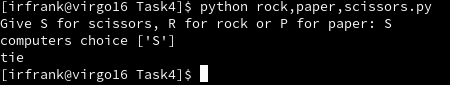

185.02857791613127
7.9822650543241185


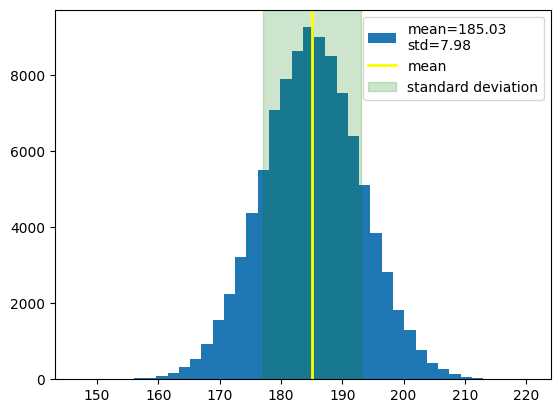

Probability to find a length of 170 or smaller in our sample is: 2.99 %
0.6826894921370867


In [3]:
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt
lengths = np.random.normal(185, 8, 100000)
mean=np.mean(lengths)
standard_deviation=np.std(lengths)
print(mean)
print(standard_deviation)

plt.hist(lengths, bins=40, label=f"mean={mean:.2f}\nstd={standard_deviation:.2f}")
plt.axvline(mean, color = 'yellow', linewidth=2, label = 'mean')
plt.axvspan(mean-standard_deviation, mean+standard_deviation, color='green', alpha=0.2, label='standard deviation')
plt.legend()
plt.show()

#calculate probability 2
h=170
cdf = norm.cdf(h, mean, standard_deviation)
P= cdf*100  #in percentage
print(f"Probability to find a length of {h} or smaller in our sample is: {P:.2f} %")

#calculate probability 2
P2= norm.cdf(mean+standard_deviation, mean, standard_deviation)- norm.cdf(mean-standard_deviation, mean, standard_deviation)
# P2= P(X<= mean+stdv) - P=(X<= mean-stdv)
print (P2)

In [4]:
import numpy as np
f=input("Give the function: ")
a=float(input("Give the lower bound: "))
b=float(input("Give the upper bound: "))

x=np.random.uniform(low=a, high=b, size=1000000)     #creates 1000000 random evenly distributed numbers for x
y=eval(f)      #evaluates the f string

integral=(b-a)*np.mean(y)     #calculate the given formula, with the mean of y, so f(x)

print(integral)

Give the function: x
Give the lower bound: 0
Give the upper bound: 1
0.5002043506601722


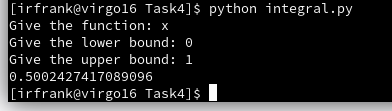

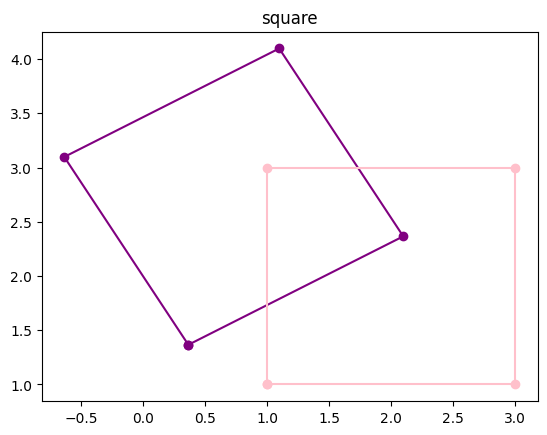

In [5]:
import matplotlib.pyplot as plt
from math import *
import numpy as np

#angle in radians
angle_degs=30
theta=np.radians(angle_degs)

#create a complex rotor with x+jy
rotor=np.cos(theta)+1j*np.sin(theta)

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

z=x+1j*y     #creates a complex number out of the x,y coordinates
zr=rotor*z   #rotating the points
xr=zr.real   #new x-coordinates
yr=zr.imag   #new y-coordinates
plt.plot(xr,yr, marker='o', color='purple')  #plot the rotated square
plt.plot(x, y, marker='o', color='pink')     #plot the square
plt.title("square") 
plt.show()

In [7]:
from math import *
import numpy as np

def funcfilter(func, seq):     #defines the function
    filtered=[]                #new list
    array=np.asarray(seq)      #create numpy array
    for x in array:            #filter the array
        if x>0:
            filtered.append(x) #add filtered data to new list
    filtered=np.asarray(filtered)     #list to array
    final = func(filtered)            #apply func to the filtered array
    return final
    
sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

result2= funcfilter(np.log10, [100])
print("Result2 log10:", result2)

Result log10: [1. 2.]
Result2 log10: [2.]


In [48]:
from math import *
from scipy import integrate
from astropy.cosmology import Planck18

H0 = Planck18.H0.value                  #in km/seconds/Mpcs
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def H(z):                               #calculates the function H(z)
    y=H0*(Om0*((1+z)**3) +Ode0)**0.5
    return y

def T_l(z):                             #calculates the function T_l(z)
    intg=1/((1+z)*H(z))
    return intg

z=2
Area = integrate.quad(T_l, 0,z)         #calculates the integral of T_l(z)

print(Area)                             #in km/seconds/Mpcs, prints the intgral

value=Area[0]                           #select only the value
print (value)

Mpcs_to_km=3.086e19                     #multiply by
scds_to_Gyr= 3.156e16                   #divide by

value=value*Mpcs_to_km/scds_to_Gyr    #convert to Gyr

print(f"The lookback time is {value} Gyr")

(0.010765276277273951, 1.7097849663277088e-15)
0.010765276277273951
The lookback time is 10.526502722328077 Gyr


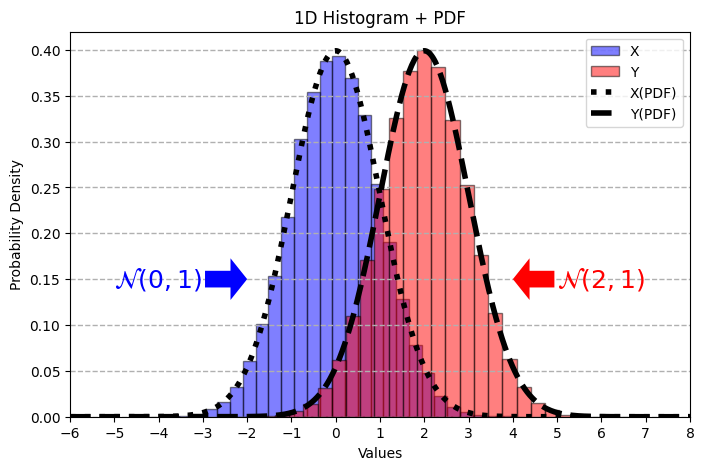

In [2]:
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt

#creating random arrays for X and Y
X = np.random.normal(0, 1, 100000)
Y = np.random.normal(2, 1, 100000)

x=np.linspace(-6,8,500)      #generating 500 evenly spread values for x between -6 and 8
pdf_X = norm.pdf(x, 0, 1)    #creating y-values, pdf of a normal distribution
pdf_Y = norm.pdf(x, 2, 1)


#creating image
plt.figure(figsize=(8,5))

#bins for bars, density so total area=1, alpha=transparent
plt.hist(X, bins=30, density=True, alpha=0.5, color="blue", edgecolor='black', label="X")
plt.hist(Y, bins=30, density=True, alpha=0.5, color="red", edgecolor='black', label="Y")
plt.plot(x, pdf_X, 'black', linewidth=4, linestyle = ':', label='X(PDF)')
plt.plot(x, pdf_Y, 'black', linewidth=4, linestyle = '--', label='Y(PDF)')

#axis label and title
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.title("1D Histogram + PDF")

#text in plot
plt.annotate(r'$\mathcal{N}(0, 1)$', 
             xy=(-2,0.15), 
             xytext=(-5,0.15),
             fontsize=18,
             color='blue',
             verticalalignment='center',
             arrowprops=dict(color='blue', width=12, headwidth=30, linewidth=0))

plt.annotate(r'$\mathcal{N}(2, 1)$', 
             xy=(4,0.15), 
             xytext=(5,0.15),
             fontsize=18,
             color='red',
             verticalalignment='center',
             arrowprops=dict(color='red', width=12, headwidth=30, linewidth=0))

#x axis values shown at range from -6 to 9 in steps of 1
plt.xticks(range(-6, 9, 1))
#x axis shows from -6 to 8
plt.xlim(-6,8)

plt.legend()
plt.grid(axis='y',linestyle = '--', linewidth = 1)
plt.show()

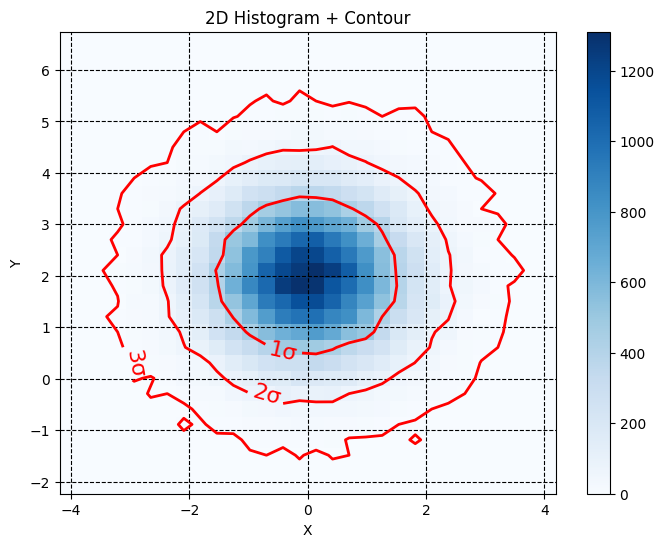

In [18]:
import numpy as np
import matplotlib.pyplot as plt

#creating random arrays for X and Y
X= np.random.normal(0,1,100000)
Y= np.random.normal(2,1,100000)

#figure size
plt.figure(figsize=(8,6))

#for every rectangle H as amount of points of data, xedge and yedge give position
H, xedges, yedges = np.histogram2d(X,Y,bins=30)

#creates the 2D histogram, 30x30 grid
plt.hist2d(X,Y,bins=30,cmap="Blues")
#createa the colorbar
plt.colorbar()

#each element of H is divided by the total number of points, turning counts into probability
H=H/H.sum()

#2D array into 1D array, H shows the probability density
Hflat=H.flatten()
#sorts the 1D array from largest to smallest
Hsorted=np.sort(Hflat)[::-1]
#calculates the cumulative sum for each element in the Hsorted list
cumsum=np.cumsum(Hsorted)

#list for density values for each level
levels=[]
for sigma in [0.68,0.95,0.997]:
    level=Hsorted[np.searchsorted(cumsum, sigma)]   #finds index where cumulative sum first reaches or exceeds sigma
    levels.append(level)                            #density value added to the new list
levels=np.sort(levels)                              #sort the new list


#find the center of each bin, gives one coordinate per bin
xcenters=(xedges[:-1]+xedges[1:])/2
ycenters=(yedges[:-1]+yedges[1:])/2

#create the red cotour lines, H.T is from H transposed so x and y are correct
#levels refers to the three levels earlier defined

cs=plt.contour(xcenters, ycenters, H.T,
              levels=levels,
              colors="red",
              linewidths=2)

#labels the contour lines
labels = {
    levels[0]: "3σ",
    levels[1]: "2σ",
    levels[2]: "1σ"
}

#labels contour lines, cs for which contour line, fmt for text
plt.clabel(cs, fmt=labels, fontsize=16)

#label the axes
plt.xlabel("X")
plt.ylabel("Y")
#x axis range from -4 to 6 in steps of 2
plt.xticks(range(-4,6,2))
#title
plt.title("2D Histogram + Contour")

#grid, true turns grid on
plt.grid(True, linestyle="--", color="black")

plt.show()